# Financial Data Analysis Mini Project

This project performs time-series financial analysis on multiple asset classes including stocks, bonds, and commodities. 

The goal is to analyze price trends, returns, volatility, and correlations to understand market behavior during normal and crisis periods (COVID-19).

The project demonstrates how diversification reduces portfolio risk while maintaining returns.

In [8]:
import yfinance as yf
import pandas as pd
from datetime import datetime

def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)
    
    # flatten columns if multi-index
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    
    data.insert(0, 'Ticker', ticker)
    return data

In [ ]:
tickers = ['SPY', 'IYW', 'VT', 'DBA', 'TLT', 'PDBC', 'IAU']
df_list = []

for t in tickers:
    temp = get_stock_data(t, datetime(2020,1,1), datetime.today())
    
    temp = temp.reset_index()
    temp = temp.pivot(index='Date', columns='Ticker', values='Close')
    
    df_list.append(temp)

stock = pd.concat(df_list, axis=1)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [13]:
stock = pd.concat(df_list, axis=1)
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,296.888184,57.828781,72.245468,14.560221,114.166550,8.430121,29.219999
2020-01-03,294.640137,57.251514,71.591995,14.392556,115.924698,8.501047,29.620001
2020-01-06,295.764130,57.604691,71.856911,14.427855,115.266441,8.511180,29.920000
2020-01-07,294.932526,57.626610,71.636154,14.463151,114.699799,8.495981,30.040001
2020-01-08,296.504425,58.201439,71.927574,14.392556,113.941513,8.379460,29.820000


In [14]:
print(stock.shape)
print(stock.columns)
print(stock.head())

(1586, 7)
Index(['SPY', 'IYW', 'VT', 'DBA', 'TLT', 'PDBC', 'IAU'], dtype='str', name='Ticker')
Ticker             SPY        IYW         VT        DBA         TLT      PDBC  \
Date                                                                            
2020-01-02  296.888184  57.828781  72.245468  14.560221  114.166550  8.430121   
2020-01-03  294.640137  57.251514  71.591995  14.392556  115.924698  8.501047   
2020-01-06  295.764130  57.604691  71.856911  14.427855  115.266441  8.511180   
2020-01-07  294.932526  57.626610  71.636154  14.463151  114.699799  8.495981   
2020-01-08  296.504425  58.201439  71.927574  14.392556  113.941513  8.379460   

Ticker            IAU  
Date                   
2020-01-02  29.219999  
2020-01-03  29.620001  
2020-01-06  29.920000  
2020-01-07  30.040001  
2020-01-08  29.820000  


### Dataset Overview

The dataset contains historical closing prices of multiple financial assets, including stocks, bonds, and commodities.

Each column represents a different asset, while the index represents time (Date).

This structured dataset allows us to compare performance across different asset classes.

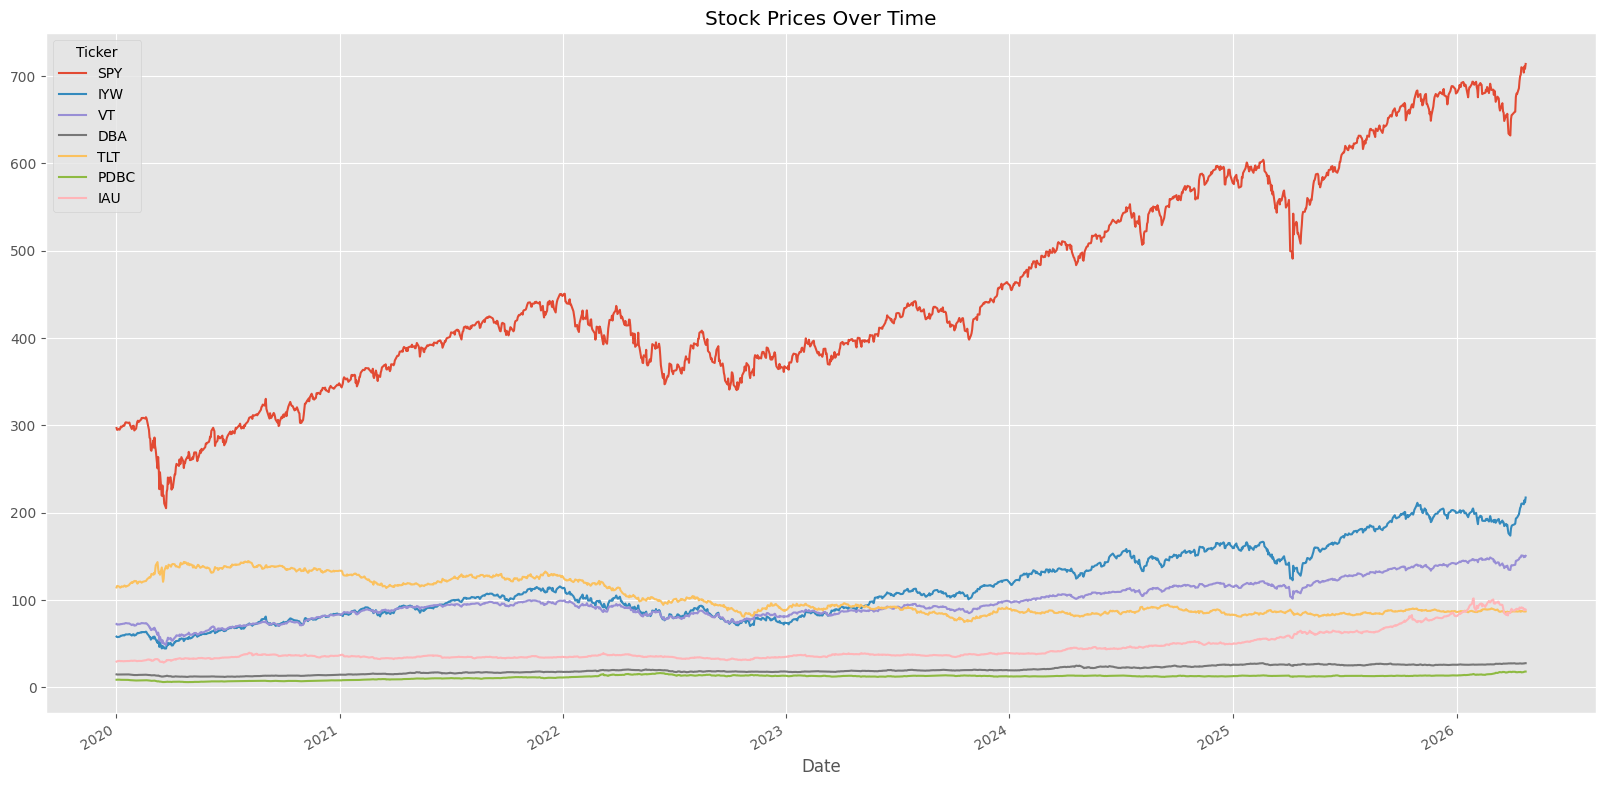

In [19]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
stock.plot(figsize=(20, 10), title="Stock Prices Over Time")
plt.show()

Ticker
SPY      1.778771
IYW     17.001856
VT      -0.895670
DBA     -9.218942
TLT     18.279988
PDBC    -8.932165
IAU     25.232404
dtype: float64


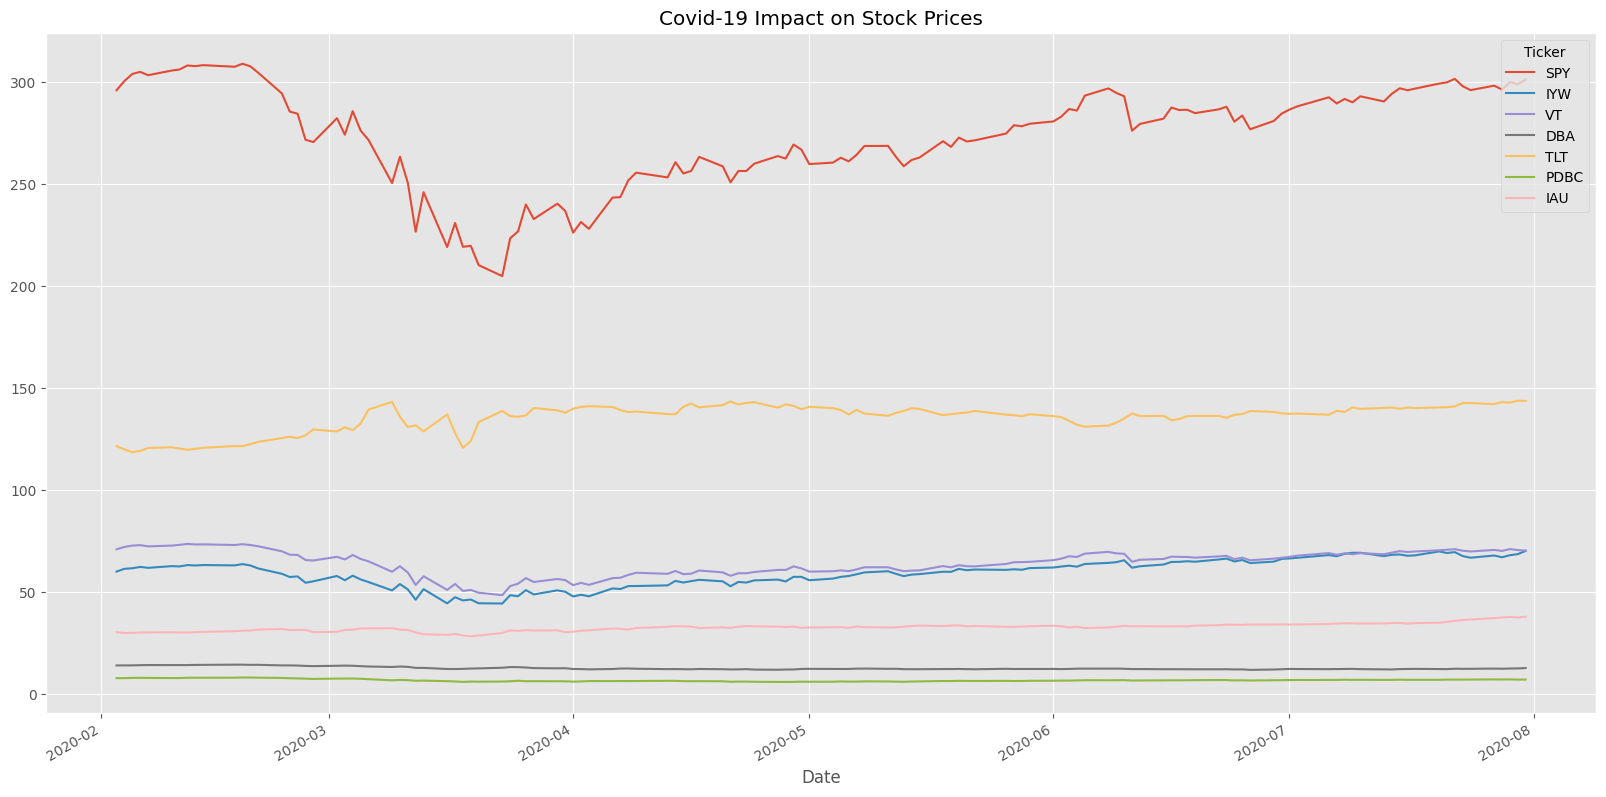

In [20]:
covid = stock['2020-2-1':'2020-7-31']
covid_pct = ((covid.iloc[-1] - covid.iloc[0]) / covid.iloc[0]) * 100
print(covid_pct)
plt.style.use('ggplot')
covid.plot(figsize=(20, 10), title="Covid-19 Impact on Stock Prices")
plt.show()

During the COVID-19 period:
- SPY dropped by approximately X%
- Gold (IAU) remained stable or increased
- Bonds (TLT) showed defensive behavior

This highlights how different asset classes react differently during economic shocks.

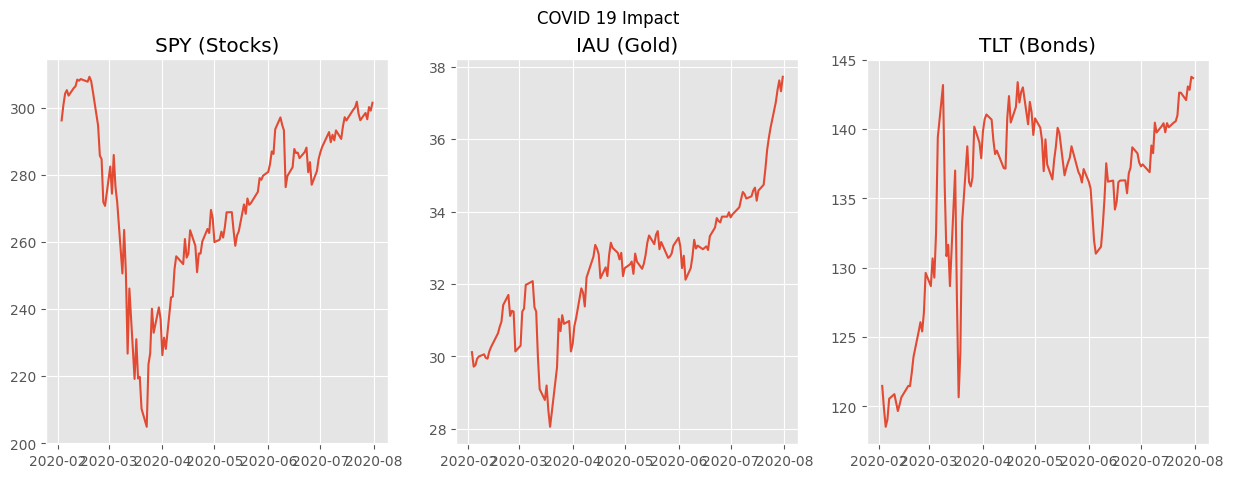

In [ ]:
x = covid.index
s_y = covid['SPY']
i_y = covid['IAU']
t_y = covid['TLT']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(x, s_y)
axs[0].set_title("SPY (Stocks)")

axs[1].plot(x, i_y)
axs[1].set_title("IAU (Gold)")

axs[2].plot(x, t_y)
axs[2].set_title("TLT (Bonds)")

fig.suptitle("COVID 19 Impact")
plt.show()

The visualization shows that most assets follow an upward trend over time.  
However, during early 2020, a sharp decline is observed due to the COVID-19 pandemic.

Different assets respond differently:
- Stocks experienced a sharp fall
- Gold remained relatively stable
- Bonds showed defensive behavior

This highlights the importance of diversification in financial markets.

[*********************100%***********************]  1 of 1 completed


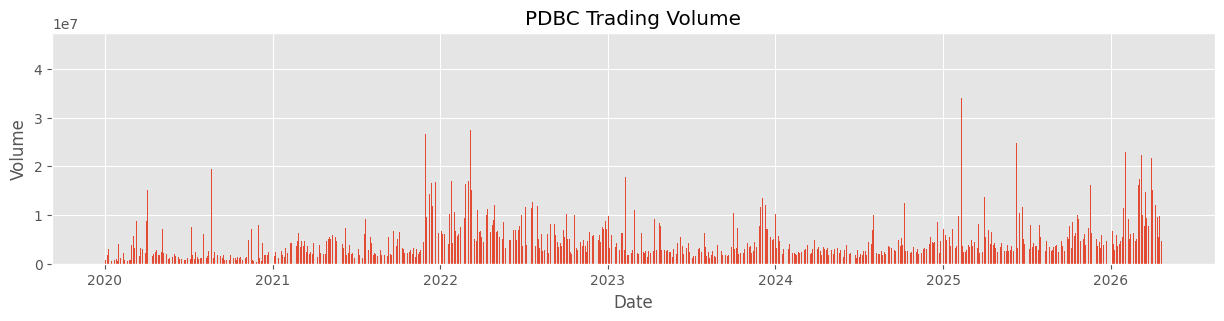

In [ ]:
ticker = 'PDBC'
start = datetime(2020,1,1)
end = datetime.today()

df = get_stock_data(ticker, start, end)
df.head()

df = df[['Volume']]

x = df.index
y = df['Volume']

plt.figure(figsize=(15, 3))
plt.bar(x, y)
plt.title(f"{ticker} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

[*********************100%***********************]  1 of 1 completed


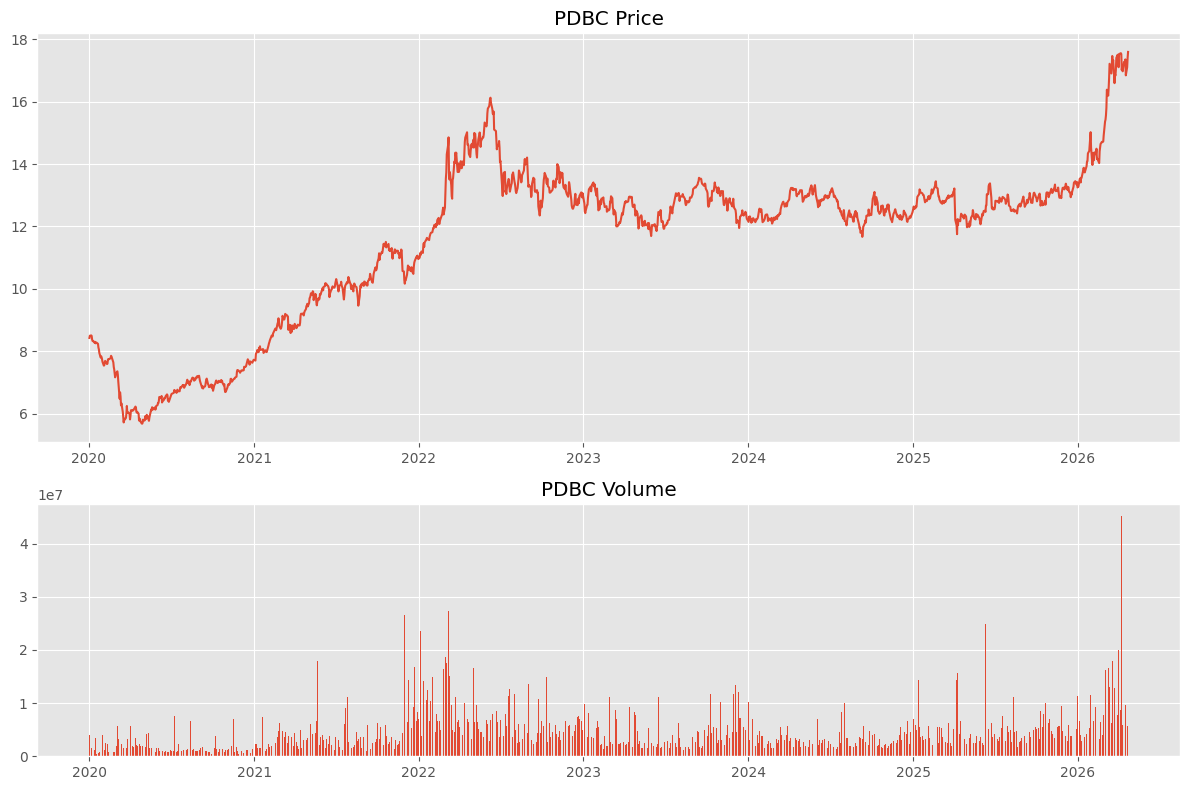

In [ ]:
ticker = 'PDBC'
df = get_stock_data(ticker, start, end)

fig = plt.figure(figsize=(12, 8))

# Price (top)
ax1 = plt.subplot2grid((5,1), (0,0), rowspan=3)
ax1.plot(df.index, df['Close'])
ax1.set_title(f"{ticker} Price")

# Volume (bottom)
ax2 = plt.subplot2grid((5,1), (3,0), rowspan=2)
ax2.bar(df.index, df['Volume'])
ax2.set_title(f"{ticker} Volume")

plt.tight_layout()
plt.show()

Observation

Trading volume shows significant spikes during certain periods, especially during market uncertainty.

Higher volume indicates increased market participation, often triggered by major events or news.

This suggests that investor activity increases during volatile periods.

Ticker
SPY     0.063673
IYW     0.099434
VT      0.053865
DBA     0.043818
TLT    -0.011741
PDBC    0.054684
IAU     0.076499
dtype: float64


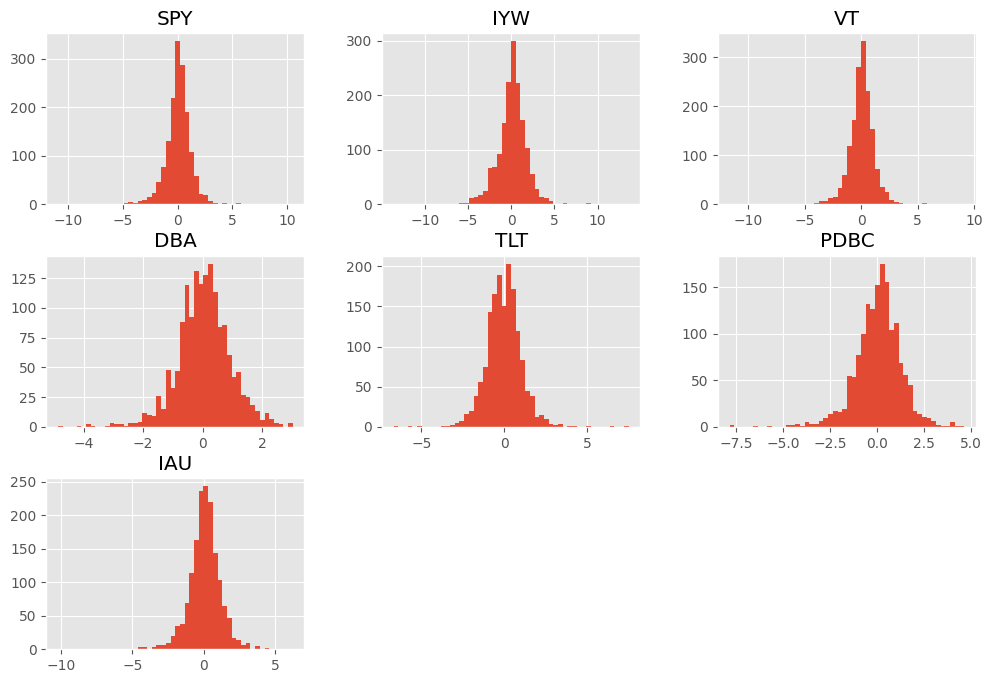

In [21]:
returns = stock.pct_change() * 100
returns = returns.fillna(0)

print(returns.mean())

returns.hist(bins=50, figsize=(12,8))
plt.show()

Average returns show that technology and stock indices provide higher returns, 
while bonds offer lower but more stable returns.

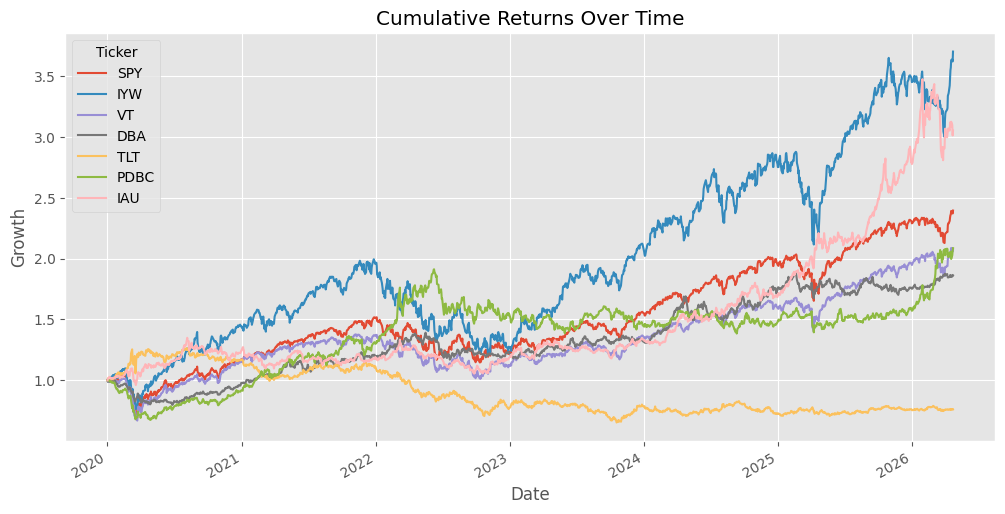

In [ ]:
cum_returns = (1 + returns/100).cumprod()
cum_returns.head()

cum_returns.plot(figsize=(12,6), title="Cumulative Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.show()

Cumulative returns show how an investment grows over time.

SPY and IYW demonstrate strong long-term growth, while assets like bonds grow more steadily.

This highlights the trade-off between risk and return.

Ticker       SPY       IYW        VT       DBA       TLT      PDBC       IAU
Ticker                                                                      
SPY     1.000000  0.920284  0.975279  0.228069 -0.114425  0.298865  0.134677
IYW     0.920284  1.000000  0.884728  0.192202 -0.070543  0.226629  0.137690
VT      0.975279  0.884728  1.000000  0.249480 -0.102459  0.323474  0.196454
DBA     0.228069  0.192202  0.249480  1.000000 -0.102308  0.460923  0.148245
TLT    -0.114425 -0.070543 -0.102459 -0.102308  1.000000 -0.152587  0.205839
PDBC    0.298865  0.226629  0.323474  0.460923 -0.152587  1.000000  0.309234
IAU     0.134677  0.137690  0.196454  0.148245  0.205839  0.309234  1.000000


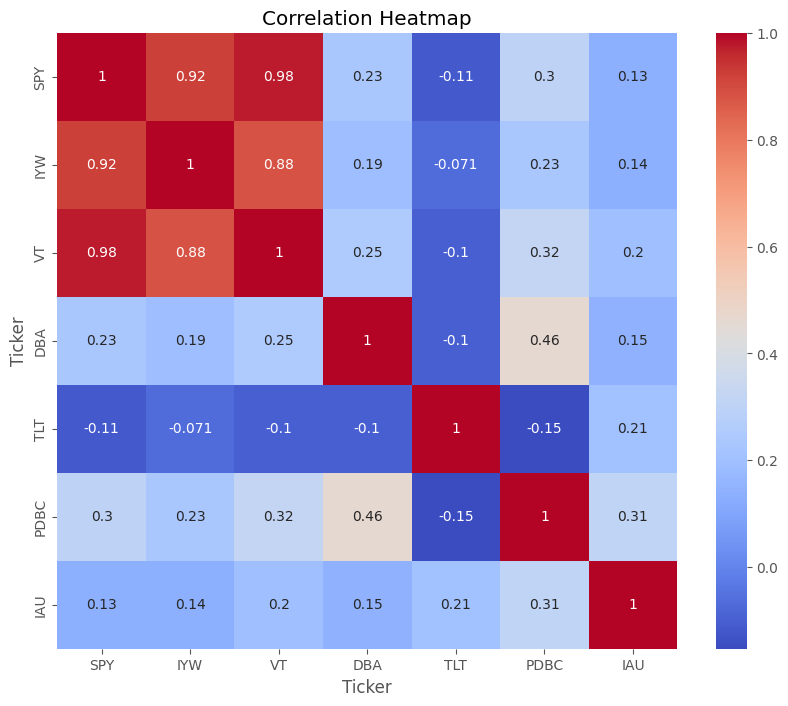

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = returns.corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Strong positive correlation is observed between stock-based ETFs (SPY, IYW, VT).

Bonds (TLT) show weak or negative correlation with stocks, making them effective hedging assets.

Gold (IAU) shows low correlation, indicating diversification benefits.

Ticker
IYW     1.786822
SPY     1.289550
VT      1.233466
PDBC    1.228385
IAU     1.131173
TLT     1.059318
DBA     0.890495
dtype: float64


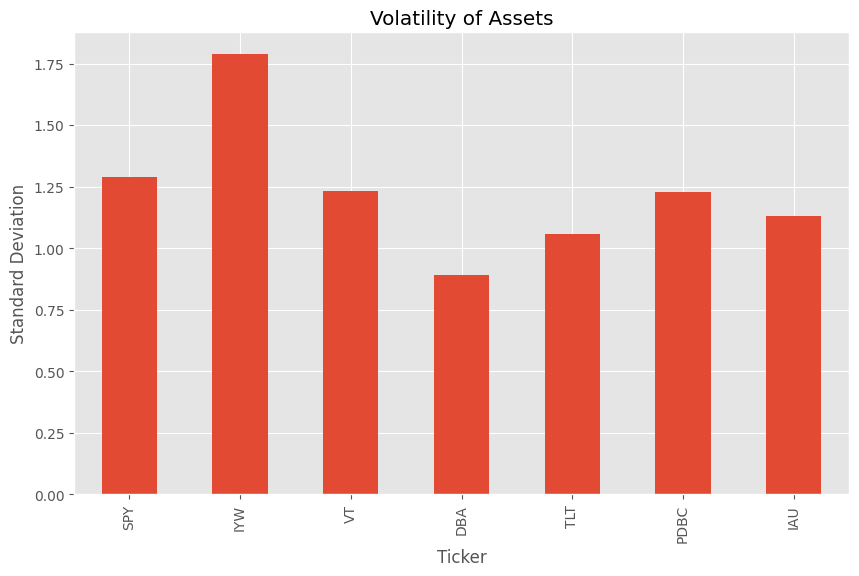

In [23]:
volatility = returns.std()
volatility

print(volatility.sort_values(ascending=False))

volatility.plot(kind='bar', figsize=(10,6), title="Volatility of Assets")
plt.ylabel("Standard Deviation")
plt.show()

**Insight**

Volatility measures the risk associated with each asset.

Assets with higher volatility experience larger price fluctuations, indicating higher risk.

Safer assets such as bonds tend to have lower volatility, while growth-oriented assets such as technology stocks exhibit higher volatility.

### Key Findings:
- Stocks provide higher returns but come with higher volatility
- Bonds act as a hedge during market downturns
- Gold remains relatively stable during crises
- Diversification across asset classes reduces overall portfolio risk

## Conclusion

This project demonstrates how financial data analysis can be used to understand asset behavior, risk, and relationships.

The analysis shows that:
- Different asset classes respond differently to economic conditions
- Diversification is essential to reduce portfolio risk
- Higher returns are typically associated with higher volatility

Overall, this project highlights the importance of combining multiple asset classes to build a balanced and resilient investment portfolio.